# 06 – CPM Interferometric Intensity Constraint

This tutorial demonstrates an extended forward model for reflection ptychography that accounts for interferometric contributions from a reference plane. It shows how the modified intensity constraint improves reconstruction of multi-layer samples.

**What you'll learn:**

- How to apply an interferometric intensity constraint in the forward model
- How to reconstruct a two-layer reflection dataset (USAF target at 700 nm)
- How the extended model compares to the standard intensity constraint

!!! note "Dataset"
    The dataset (`USAF_speckle_bin4.hdf5`) is downloaded automatically into the `example_data/` folder at the project root the first time you run the notebook. If the file already exists it is not re-downloaded.

!!! tip "Prerequisites"
    Complete [05 – CPM Reflection](tutorial_reflectionPtychography.ipynb) before this tutorial.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import h5py

In [2]:
# import the PtyLab module
import PtyLab
from PtyLab import ExperimentalData
from PtyLab import Reconstruction
from PtyLab import Monitor
from PtyLab import Params
from PtyLab import Engines
from PtyLab.utils.utils import posit

The dataset (`USAF_speckle_bin4.hdf5`) is downloaded automatically into the `example_data/` folder at the project root the first time you run the next cell. If the file already exists it is not re-downloaded.

In [3]:
from PtyLab.io import getExampleDataFolder
import urllib.request

fileName = "USAF_speckle_bin4.hdf5"
filePath = getExampleDataFolder() / fileName

if not filePath.exists():
    print(f"Downloading {fileName}...")
    urllib.request.urlretrieve(
        "https://ndownloader.figshare.com/files/28713885",
        filePath,
    )
    print("Download complete.")
else:
    print(f"{fileName} found, skipping download.")

USAF_speckle_bin4.hdf5 found, skipping download.


In [4]:
experimentalData = ExperimentalData(filePath, operationMode="CPM")
experimentalData.zo = 25.02e-3
experimentalData.entrancePupilDiameter = (
    0.4e-3  # exampleData.Np / 3 * exampleData.dxp  # initial estimate of beam size
)
backgroundOffset = 20
experimentalData.ptychogram = posit(experimentalData.ptychogram - backgroundOffset)
# experimentalData.showPtychogram()

Found encoder with shape (102, 2)


In [5]:
# Set monitor properties
monitor = Monitor()
monitor.figureUpdateFrequency = 1
monitor.objectPlot = "complex"  # complex abs angle
monitor.verboseLevel = "high"  # high: plot two figures, low: plot only one figure
monitor.probeZoom = 1  # control probe plot FoV
monitor.objectZoom = 2  # control object plot FoV
monitor.objectPlotContrast = 0.8
monitor.probePlotContrast = 0.5

/mnt/home/shantanu/projects/PtyLab.py/PtyLab/Monitor/Monitor.py:178: UserWarning: For faster update of the reconstruction plot, set `monitor.figureUpdateFrequency = 5` or higher.
  warnings.warn(
/mnt/home/shantanu/projects/PtyLab.py/PtyLab/Monitor/Monitor.py:191: UserWarning: For diffraction data plot, preferably use an interactive matplotlib backend or set `monitor.verboseLevel = "low"`. 
  warnings.warn(


In [6]:
# Set the reconstruction parameters
params = Params()
## switches
params.gpuSwitch = True
params.positionOrder = "random"  # 'sequential' or 'random'
params.propagator = (
    "Fraunhofer"  # Fraunhofer Fresnel ASP scaledASP polychromeASP scaledPolychromeASP
)
params.probePowerCorrectionSwitch = True
params.comStabilizationSwitch = True
params.fftshiftSwitch = False
params.backgroundModeSwitch = True

INFO:GPU:cupy and CUDA available, switching to GPU


In [7]:
reconstruction = Reconstruction(experimentalData, params)
reconstruction.No = 2**11
reconstruction.initialProbe = "circ"
reconstruction.initialObject = "ones"
# initialize probe and object and related params
reconstruction.initializeObjectProbe()

# customize initial probe quadratic phase
reconstruction.probe = reconstruction.probe * np.exp(
    1.0j
    * 2
    * np.pi
    / reconstruction.wavelength
    * (reconstruction.Xp**2 + reconstruction.Yp**2)
    / (3 * 6e-3)
)

INFO:Reconstruction:Copying attribute wavelength
INFO:Reconstruction:Copying attribute dxd
INFO:Reconstruction:Copying attribute theta
INFO:Reconstruction:Copying attribute spectralDensity
INFO:Reconstruction:Copying attribute entrancePupilDiameter
INFO:Reconstruction:Initial object set to ones
INFO:Reconstruction:Initial probe set to circ


We first use the standard intensityConstraint, which means that the USAF sample is considered as a thin single-layer object

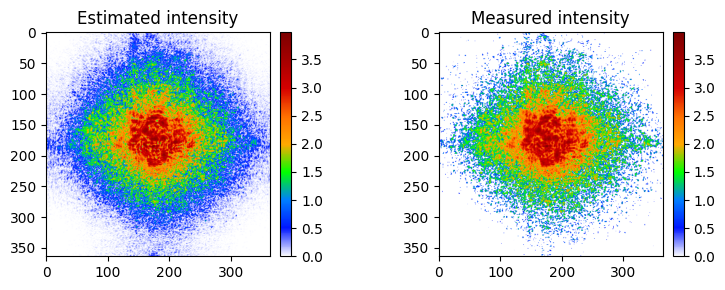

                                                      
iteration: 99                                         
error: 21.4                                           
estimated linear overlap: 74.5 %                      
estimated area overlap: 79.0 %                        
mPIE: 100%|██████████| 100/100 [00:36<00:00,  2.73it/s]

INFO:mPIE:switch to cpu


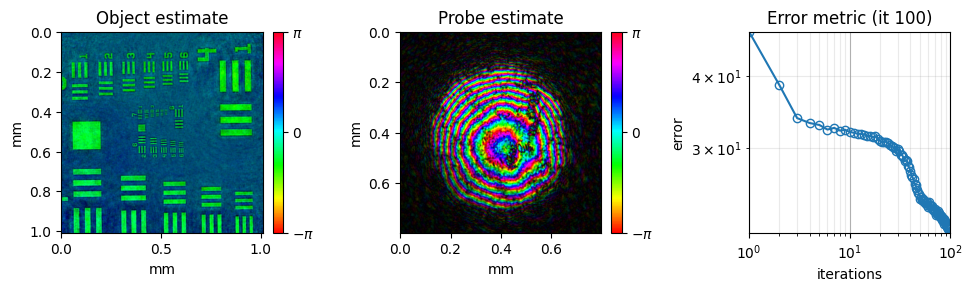

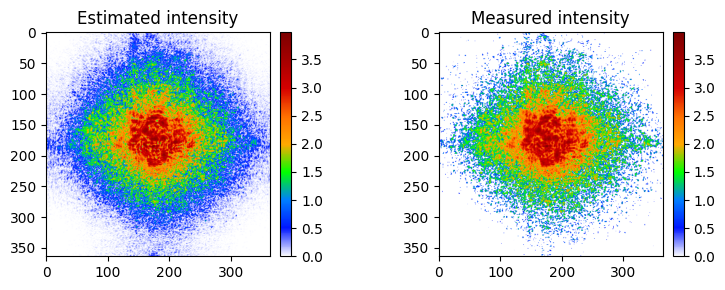

In [8]:
params.intensityConstraint = "standard"

mPIE = Engines.mPIE(reconstruction, experimentalData, params, monitor)
mPIE.numIterations = 100
mPIE.betaProbe = 0.05
mPIE.betaObject = 0.25
mPIE.reconstruct()

Now we switch to interferometric constraint, which takes into account the extra reflection from the plane side of the USAF glass substrate, and treats it as an external 'reference'. The results show that the noise in object reconstruction is significantly cleaned up.

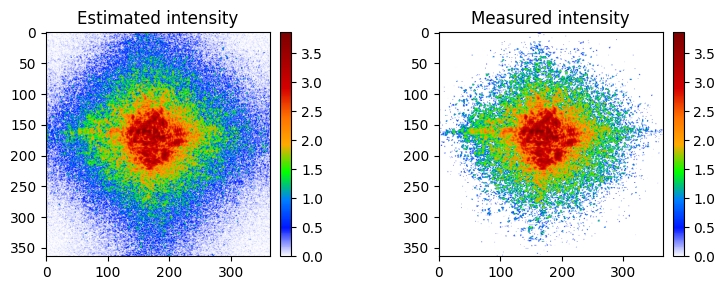

                                                       
iteration: 199                                         
error: 16.3                                            
estimated linear overlap: 74.0 %                       
estimated area overlap: 77.4 %                         
mPIE: 100%|██████████| 200/200 [01:12<00:00,  2.74it/s]

INFO:mPIE:switch to cpu


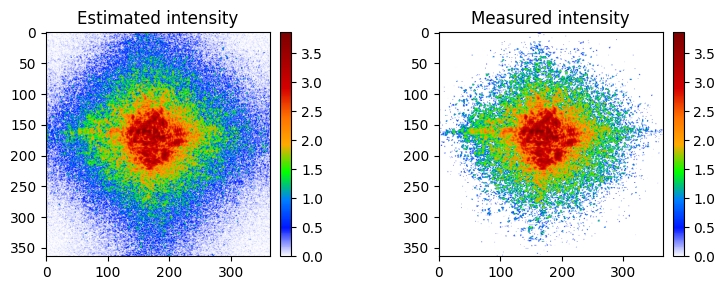

In [9]:
params.intensityConstraint = "interferometric"

mPIE = Engines.mPIE(reconstruction, experimentalData, params, monitor)
mPIE.numIterations = 200
mPIE.betaProbe = 0.25
mPIE.betaObject = 0.25
mPIE.reconstruct()

In [10]:
## now save the data
# reconstruction.saveResults('reconstruction.hdf5')